# Velorama GRN Inference Pipeline
### Hepatocytes → Cholangiocytes · GSE202379 · End-stage disease

**What this notebook does:**
1. Installs Velorama from source (run once)
2. Loads & preprocesses the filtered AnnData (raw counts)
3. Builds a pseudotime trajectory (DPT via diffusion maps)
4. Annotates TF regulators and target genes
5. Saves the prepared AnnData that Velorama expects
6. Runs Velorama from within the notebook via subprocess
7. Loads, cleans, and visualises the inferred GRN

> **Velorama reference:** Rohit Singh et al., *Cell Systems* 2024  
> https://github.com/rs239/velorama

In [ ]:
# import subprocess, sys, os

# # ── clone if not already present ────────────────────────────────────────────
# VELORAMA_DIR = os.path.expanduser("C:/Users/Floarea/Desktop/corebioinfo/velorama-main")  # change path if you prefer

# if not os.path.isdir(VELORAMA_DIR):
#     print("Cloning velorama ...")
#     subprocess.run(
#         ["git", "clone", "https://github.com/rs239/velorama.git", VELORAMA_DIR],
#         check=True
#     )

# # ── install into current Python environment ──────────────────────────────────
# env = os.environ.copy()
# env["SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL"] = "True"

# subprocess.run(
#     [sys.executable, "-m", "pip", "install", "."],
#     cwd=VELORAMA_DIR,
#     env=env,
#     check=True
# )

# print("\n✅ Velorama installed — RESTART THE KERNEL, then continue from Cell 1")


✅ Velorama installed — RESTART THE KERNEL, then continue from Cell 1


---
## Cell 1 · Imports

In [2]:
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 2          # 0=errors, 1=warnings, 2=info, 3=hints
sc.settings.set_figure_params(dpi=100, facecolor="white")

# ── paths (edit these two lines if needed) ───────────────────────────────────
H5AD_PATH    = r"C:/Users/Floarea/Desktop/corebioinfo/R codes/data/GSE202379_fitlered.h5ad"
OUTPUT_DIR   = r"C:/Users/Floarea/Desktop/corebioinfo/velorama_output"   # will be created
VELORAMA_DIR = os.path.expanduser("~/velorama")   # where you cloned the repo

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output folder:", OUTPUT_DIR)

c:\Users\Floarea\miniconda3\envs\velorama\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output folder: C:/Users/Floarea/Desktop/corebioinfo/velorama_output


---
## Cell 2 · Load data & restore raw counts

Velorama performs its own internal normalisation.  
We **always** start from integer raw counts stored in `adata.layers['counts']`.

In [ ]:
adata = sc.read_h5ad(H5AD_PATH)

shared_cells = open("shared_cells.txt").read().splitlines()
adata = adata[adata.obs_names.isin(shared_cells)].copy()

shared_genes = open("shared_genes.txt").read().splitlines()
adata = adata[:, adata.var_names.isin(shared_genes)].copy()

pt = pd.read_csv("shared_pseudotime.csv", index_col=0)
adata.obs["dpt_pseudotime"] = pt.reindex(adata.obs_names)["pseudotime"]

print("Loaded:", adata)
print("Cell annotations:", adata.obs["cell.annotation"].value_counts().to_dict())

# ── restore raw integer counts ───────────────────────────────────────────────
# The R export wrote raw counts into layers['counts']; reset .X to that layer.
adata.X = adata.layers["counts"].copy()

if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)

# Sanity check: counts should be non-negative integers
sample = adata.X[:100].toarray() if sp.issparse(adata.X) else adata.X[:100]
assert (sample >= 0).all(), "Negative values found — check your counts layer"
assert np.allclose(sample, sample.astype(int)), "Non-integer values found — check your counts layer"
print("✅ Raw integer counts confirmed")

Loaded: AnnData object with n_obs × n_vars = 25527 × 31257
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Patient.ID', 'Disease.status', 'non.NAFLD.disease', 'Lobe', 'manuscript.expt', 'SAF.Score', 'Steatosis', 'Ballooning', 'Inflammation', 'Fibrosis.score..F0.4.', 'Gender', 'Age', 'BMI', 'Ethnic.group', 'Diabetes.type.2', 'hypertension', 'dyslipidaemia', 'cardiovascular.disease', 'obstructive.sleep.apnoea', 'percent.mt.RNA', 'percent.rp.RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'SCT_snn_res.0.3', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'SCT_snn_res.0.9', 'SCT_snn_res.1.1', 'SCT_snn_res.1.3', 'SCT_snn_res.1.5', 'SCT_snn_res.2', 'seurat_clusters', 'cell.annotation.version', 'cell.annotation', 'SCT_snn_orig.0.1', 'SCT_snn_res.0.4', 'SCT_snn_orig.0.4', 'SCT_snn_res.0.8', 'SCT_snn_orig.0.8', 'SCT_snn_res.1.2', 'SCT_snn_orig.1.2', 'SCT_snn_res.1.6', 'SCT_snn_orig.1.6', 'SCT_snn_harmony_t.0.0.1', 'SCT_snn_harmony_t.0.0.4', 'SCT_snn_harmony_t.0.0.8', 'SCT_snn_harmony_t.0.1.2

---
## Cell 3 · Basic quality-control filtering

In [4]:
print(f"Before QC: {adata.n_obs} cells × {adata.n_vars} genes")

# Remove low-quality cells and rarely-detected genes
sc.pp.filter_cells(adata, min_genes=200)   # cells with <200 detected genes
sc.pp.filter_genes(adata, min_cells=10)    # genes detected in <10 cells

print(f"After QC:  {adata.n_obs} cells × {adata.n_vars} genes")

Before QC: 25527 cells × 31257 genes
filtered out 5080 genes that are detected in less than 10 cells
After QC:  25527 cells × 26177 genes


---
## Cell 4 · Normalise → log1p (used for PCA, neighbours, UMAP, Velorama)

Velorama's README recommends *normalised + log-transformed* counts as input  
(unlike some GRN tools that need raw counts). We store raw counts safely in a layer.

In [5]:
# Keep raw counts in a dedicated layer for reference
adata.layers["raw_counts"] = adata.X.copy()

# Normalise to median total counts per cell, then log-transform
sc.pp.normalize_total(adata)    # scale each cell to median library size
sc.pp.log1p(adata)              # log(x + 1) stabilises variance

print("Normalisation done. adata.X is now log-normalised.")

normalizing counts per cell
    finished (0:00:14)
Normalisation done. adata.X is now log-normalised.


---
## Cell 5 · Highly variable genes (speeds up downstream steps)

extracting highly variable genes
HVGs selected: 3000


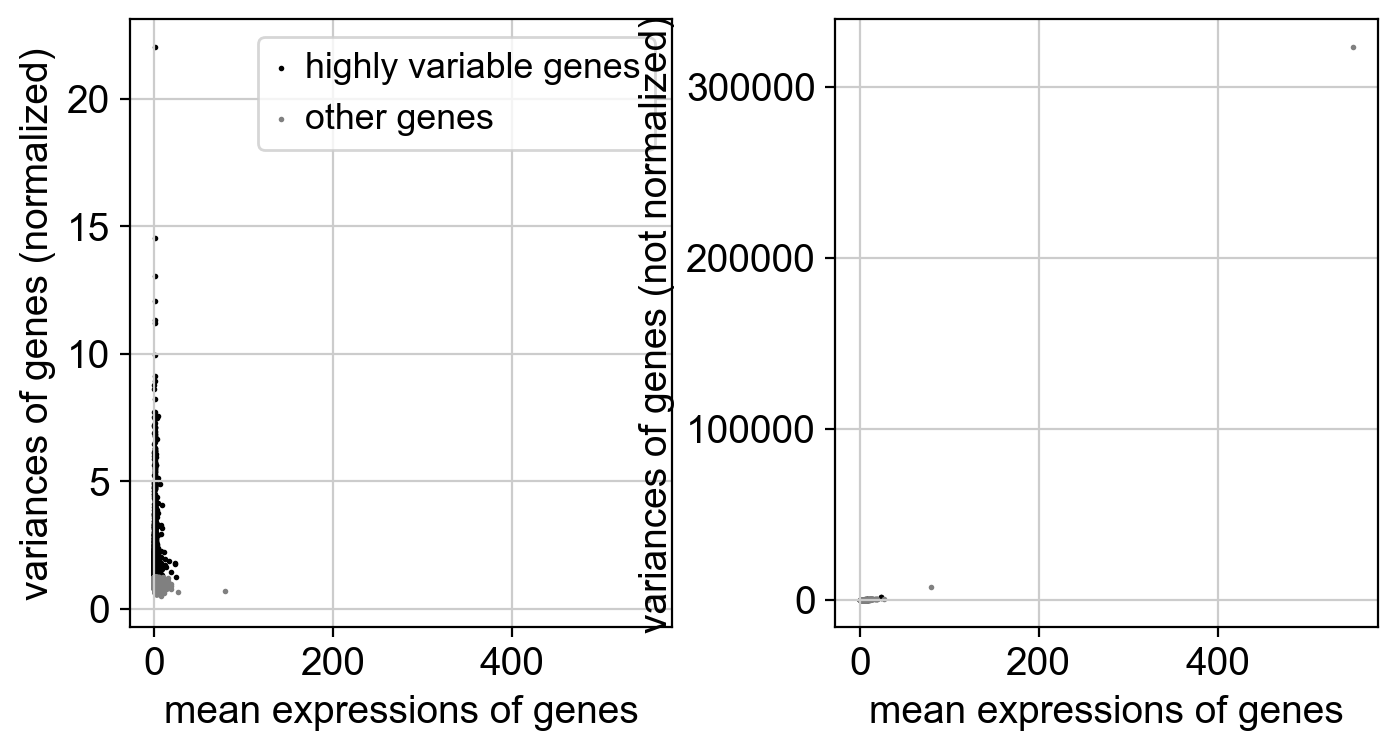

In [6]:
# Select top 3000 highly variable genes — enough signal, tractable compute
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3",
                             layer="raw_counts")  # HVG selection on raw counts

print(f"HVGs selected: {adata.var.highly_variable.sum()}")
sc.pl.highly_variable_genes(adata)

---
## Cell 6 · PCA → Neighbourhood graph → UMAP → Leiden clustering

computing PCA
    with n_comps=50


c:\Users\Floarea\miniconda3\envs\velorama\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:09)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:01:21)
computing UMAP
    finished (0:00:43)
running Leiden clustering


C:\Users\Floarea\AppData\Local\Temp\ipykernel_1312\1839268959.py:11: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added="leiden")


    finished (0:00:05)


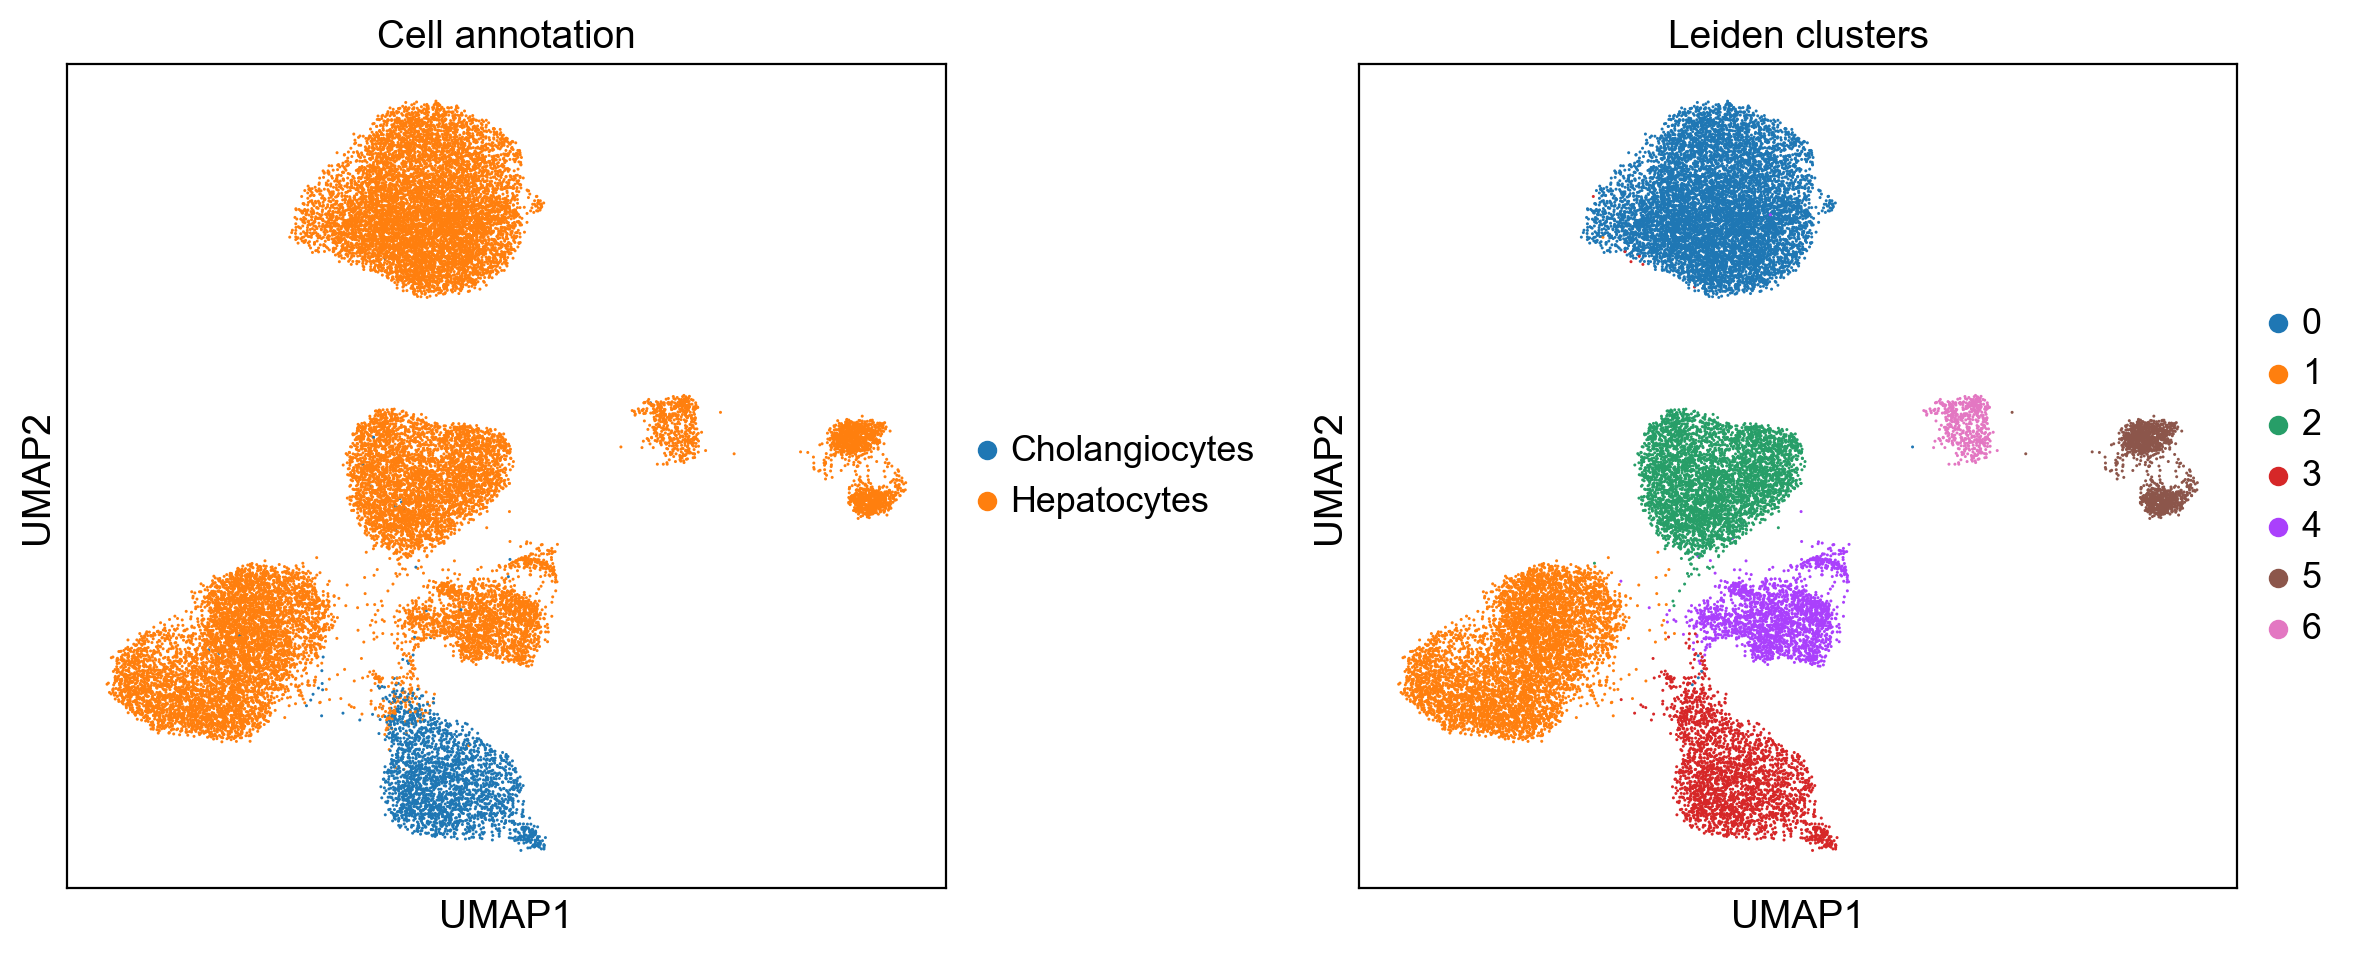

In [7]:
# PCA on the HVG subset
sc.pp.pca(adata, use_highly_variable=True, n_comps=50)

# k-nearest-neighbour graph in PC space
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

# UMAP embedding for visualisation
sc.tl.umap(adata)

# Leiden clustering (resolution controls granularity; 0.5 is a good default)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden")

# Visualise clusters alongside known cell annotation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.pl.umap(adata, color="cell.annotation", ax=axes[0], show=False, title="Cell annotation")
sc.pl.umap(adata, color="leiden",          ax=axes[1], show=False, title="Leiden clusters")
plt.tight_layout()
plt.show()

---
## Cell 7 · Diffusion map + DPT pseudotime

Velorama builds its cell DAG from pseudotime.  
We use Scanpy's diffusion pseudotime (DPT), anchored at the most mature  
hepatocyte (cell type expected to be the differentiation root in end-stage liver).

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9977866  0.9958546  0.99484366 0.988886   0.9792893
     0.97244173 0.96793115 0.9637517  0.953254   0.9463392  0.9412194
     0.93588406 0.93485427 0.9267856 ]
    finished (0:00:01)
Root cell index: 17424  (barcode: TAGTGCATCCCAGCGA-7)
computing Diffusion Pseudotime using n_dcs=10
    finished (0:00:00)


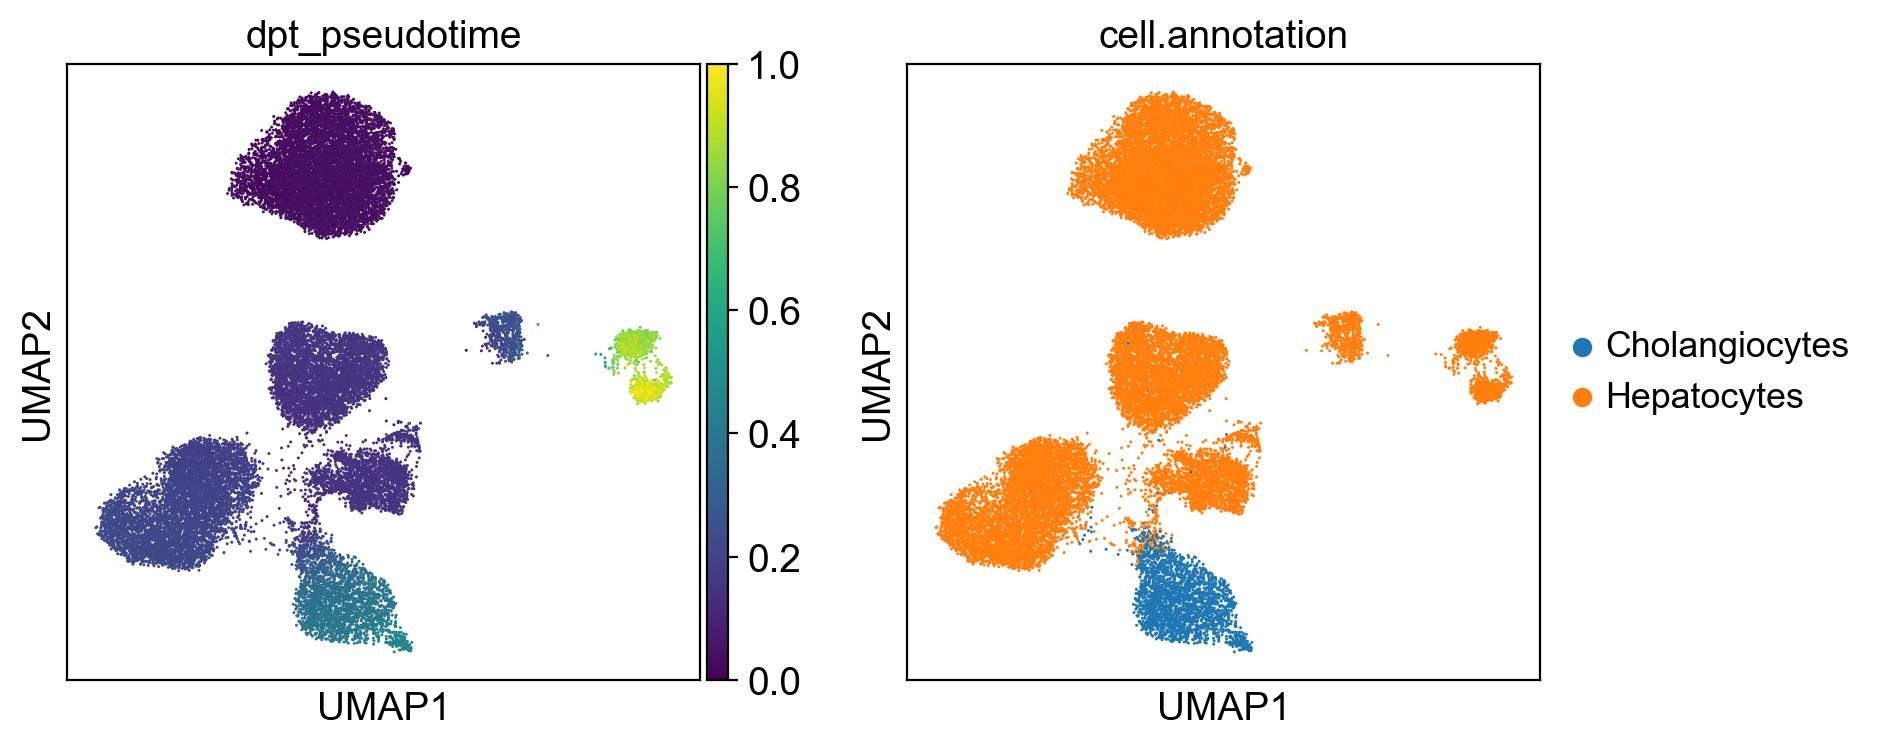

In [8]:
# ── diffusion map: captures continuous manifold structure ────────────────────
sc.tl.diffmap(adata, n_comps=15)

# ── pick a root cell ─────────────────────────────────────────────────────────
# We anchor on a Hepatocyte with low diffusion-component-1 value
# (tends to correspond to undifferentiated / early state on the trajectory).
# Adjust if biological knowledge suggests a different root.
hepatocyte_idx = np.where(adata.obs["cell.annotation"] == "Hepatocytes")[0]

# Root = hepatocyte with smallest DC1 value (one end of the trajectory)
dc1_vals = adata.obsm["X_diffmap"][hepatocyte_idx, 0]
root_local = np.argmin(dc1_vals)           # index within hepatocyte_idx
adata.uns["iroot"] = int(hepatocyte_idx[root_local])

print(f"Root cell index: {adata.uns['iroot']}  "
      f"(barcode: {adata.obs_names[adata.uns['iroot']]})")

# ── DPT ─────────────────────────────────────────────────────────────────────
sc.tl.dpt(adata, n_dcs=10)

# Visualise pseudotime on UMAP
sc.pl.umap(adata, color=["dpt_pseudotime", "cell.annotation"],
           color_map="viridis", ncols=2)

---
## Cell 8 · PAGA (optional — branch topology overview)

PAGA gives a clean picture of how Hepatocytes and Cholangiocytes connect.  
`draw_graph` uses PAGA positions as initialisation — much faster than random.

In [9]:
# # PAGA graph on cell-type labels
# sc.tl.paga(adata, groups="cell.annotation")
# sc.pl.paga(adata, color=["cell.annotation"], title="PAGA — cell annotation")

# # Force-directed layout initialised from PAGA (lighter alternative to full UMAP rerun)
# # NOTE: this can be slow on large datasets; comment out if not needed
# sc.tl.draw_graph(adata, init_pos="paga", random_state=42)
# sc.pl.draw_graph(adata, color=["cell.annotation", "dpt_pseudotime"], legend_loc="on data")

---
## Cell 9 · Define TF regulators and target genes for Velorama

Velorama requires two boolean columns in `adata.var`:
- `is_reg`    — candidate **transcription factor** regulators
- `is_target` — candidate **target** genes

We use the **AnimalTFDB** human TF list as regulators, and all HVGs as targets.  
You can substitute any curated TF list (e.g. from JASPAR, ENCODE, or a liver-specific resource).

In [10]:
# ── Option A: download a public human TF list (AnimalTFDB v4) ────────────────
# This table lists all human TFs with their gene symbols.
# We attempt a download; fall back to a minimal hard-coded liver TF list.

try:
    tf_df = pd.read_csv(
        "https://tf.guntherics.de/v4/human/TF_Ensembl_v_1.01.txt",
        sep="\t"
    )
    tf_symbols = set(tf_df["Symbol"].dropna().str.upper())
    print(f"AnimalTFDB: {len(tf_symbols)} human TFs loaded")

except Exception:
    # ── Fallback: manually curated liver / biliary TFs ─────────────────────
    # Key hepatocyte TFs: HNF4A, HNF1A, FOXA2, NR1H4 (FXR), CEBPA
    # Key cholangiocyte TFs: SOX9, HNF1B, KRT19 (marker, not TF — exclude)
    tf_symbols = {
        "HNF4A", "HNF1A", "HNF1B", "FOXA1", "FOXA2", "FOXA3",
        "CEBPA", "CEBPB", "NR1H4", "NR5A2", "RXRA", "RXRB",
        "SOX9", "SOX4", "SP1", "SP3", "GATA4", "GATA6",
        "TP53", "MYC", "E2F1", "E2F3", "YAP1", "TEAD1", "TEAD4",
        "STAT3", "SMAD2", "SMAD3", "TCF7L2", "CTNNB1",
        "ATF2", "ATF3", "ATF5", "CREB1", "MAFG", "MAFK",
        "NFE2L2", "PPARA", "PPARG", "MLXIPL", "KLF6",
    }
    print(f"Using fallback TF list: {len(tf_symbols)} TFs")

# ── Map to genes actually present in adata ──────────────────────────────────
gene_names_upper = adata.var_names.str.upper()

# is_reg: TF present in our dataset
adata.var["is_reg"] = gene_names_upper.isin(tf_symbols)

# is_target: all highly variable genes are candidate targets
# (restrict to HVGs to keep the problem tractable on CPU)
adata.var["is_target"] = adata.var["highly_variable"].values

print(f"\nRegulators (TFs in dataset): {adata.var['is_reg'].sum()}")
print(f"Targets (HVGs):              {adata.var['is_target'].sum()}")
print("\nTF regulators found:")
print(adata.var_names[adata.var["is_reg"]].tolist())

Using fallback TF list: 41 TFs

Regulators (TFs in dataset): 41
Targets (HVGs):              3000

TF regulators found:
['NR5A2', 'ATF3', 'SP3', 'ATF2', 'NFE2L2', 'CREB1', 'PPARG', 'CTNNB1', 'E2F3', 'SOX4', 'RXRB', 'MAFK', 'MLXIPL', 'GATA4', 'RXRA', 'KLF6', 'TCF7L2', 'TEAD1', 'YAP1', 'TEAD4', 'SP1', 'NR1H4', 'HNF1A', 'FOXA1', 'SMAD3', 'TP53', 'HNF1B', 'STAT3', 'SOX9', 'MAFG', 'GATA6', 'SMAD2', 'CEBPA', 'FOXA3', 'ATF5', 'FOXA2', 'E2F1', 'HNF4A', 'CEBPB', 'PPARA', 'MYC']


---
## Cell 10 · Save the prepared AnnData for Velorama

Velorama is invoked as a **command-line tool** and reads a single `.h5ad` file.  
The filename (without extension) is passed as `--dataset` / `-ds`.

In [11]:
DATASET_NAME = "liver_endstage"   # used as Velorama's -ds argument
save_path    = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad")

adata.write_h5ad(save_path)
print(f"✅ AnnData saved to: {save_path}")
print(f"   Shape: {adata.n_obs} cells × {adata.n_vars} genes")

✅ AnnData saved to: C:/Users/Floarea/Desktop/corebioinfo/velorama_output\liver_endstage.h5ad
   Shape: 25527 cells × 26177 genes


In [12]:
import os, sys
import scanpy as sc
import numpy as np

# ── paths ────────────────────────────────────────────────────────────────────
OUTPUT_DIR   = r"C:/Users/Floarea/Desktop/corebioinfo/velorama_output"
DATASET_NAME = "liver_endstage"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_CELLS      = 300
N_TF_TARGETS = 150

print(f"Full adata: {adata.n_obs} cells × {adata.n_vars} genes")

# ── 1. Subsample cells ───────────────────────────────────────────────────────
adata_sub = adata.copy()
sc.pp.subsample(adata_sub, n_obs=N_CELLS, random_state=42)
print(f"After cell subsample: {adata_sub.n_obs} cells")

# ── 2. Subset genes: all TFs + top N target HVGs ────────────────────────────
tfs = adata_sub.var_names[adata_sub.var["is_reg"]]
targets = (
    adata_sub.var[adata_sub.var["highly_variable"]]
    .pipe(lambda df: df.nlargest(N_TF_TARGETS, "dispersions_norm")
          if "dispersions_norm" in df.columns
          else df.head(N_TF_TARGETS))
    .index
)
keep = tfs.union(targets)
adata_sub = adata_sub[:, keep].copy()

adata_sub.var["is_reg"]    = adata_sub.var_names.isin(tfs)
adata_sub.var["is_target"] = adata_sub.var_names.isin(targets)

print(f"Final matrix : {adata_sub.n_obs} cells × {adata_sub.n_vars} genes")
print(f"  Regulators : {adata_sub.var['is_reg'].sum()}")
print(f"  Targets    : {adata_sub.var['is_target'].sum()}")

# ── 3. Recompute neighbourhood graph + diffmap on the subsample ──────────────
# These must be rerun because cell indices changed after subsetting
print("\nRecomputing graph + diffmap on subsample...")
sc.pp.neighbors(adata_sub, n_neighbors=15, n_pcs=20)  # smaller n_neighbors for 300 cells
sc.tl.diffmap(adata_sub, n_comps=10)

# ── 4. Set iroot to a valid index within the subsample ──────────────────────
# Find hepatocytes in the subsampled obs and pick the one with lowest DC1
hepato_mask = adata_sub.obs["cell.annotation"] == "Hepatocytes"
hepato_idx  = np.where(hepato_mask)[0]

if len(hepato_idx) == 0:
    # Fallback: if no hepatocytes in this subsample, just use cell 0
    print("⚠️  No Hepatocytes in subsample — using cell 0 as root")
    adata_sub.uns["iroot"] = 0
else:
    dc1_vals = adata_sub.obsm["X_diffmap"][hepato_idx, 0]
    root_local = np.argmin(dc1_vals)
    adata_sub.uns["iroot"] = int(hepato_idx[root_local])

print(f"iroot set to: {adata_sub.uns['iroot']}  "
      f"(barcode: {adata_sub.obs_names[adata_sub.uns['iroot']]})")

# ── 5. Recompute DPT on the subsample ───────────────────────────────────────
sc.tl.dpt(adata_sub, n_dcs=10)
print(f"dpt_pseudotime range: "
      f"{adata_sub.obs['dpt_pseudotime'].min():.3f} – "
      f"{adata_sub.obs['dpt_pseudotime'].max():.3f}")

# ── 6. Save ─────────────────────────────────────────────────────────────────
save_path = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad")

# ── cast to Float32 — Velorama's torch code requires this ───────────────────
import scipy.sparse as sp

if sp.issparse(adata_sub.X):
    adata_sub.X = adata_sub.X.astype(np.float32)
else:
    adata_sub.X = adata_sub.X.astype(np.float32)

# Also cast any layers that might be read by Velorama
for layer_key in adata_sub.layers:
    if sp.issparse(adata_sub.layers[layer_key]):
        adata_sub.layers[layer_key] = adata_sub.layers[layer_key].astype(np.float32)
    else:
        adata_sub.layers[layer_key] = adata_sub.layers[layer_key].astype(np.float32)

print(f"X dtype: {adata_sub.X.dtype}")  # should print float32

# ── save ─────────────────────────────────────────────────────────────────────
save_path = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad")
adata_sub.write_h5ad(save_path)
print(f"✅ Saved → {save_path}")

adata_sub.write_h5ad(save_path)
print(f"\n✅ Saved → {save_path}")
print(f"   RAM estimate for scale step: "
      f"{adata_sub.n_obs * adata_sub.n_vars * 8 / 1e9:.3f} GiB")

Full adata: 25527 cells × 26177 genes
After cell subsample: 300 cells
Final matrix : 300 cells × 191 genes
  Regulators : 41
  Targets    : 150

Recomputing graph + diffmap on subsample...
computing neighbors
    using 'X_pca' with n_pcs = 20
    finished (0:00:05)
computing Diffusion Maps using n_comps=10(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.98512477 0.9776331  0.96849144 0.95387167 0.8614972
     0.8289186  0.8217236  0.7719234  0.76355433]
    finished (0:00:00)
iroot set to: 268  (barcode: TTACTGTTCACCTCGT-58)
computing Diffusion Pseudotime using n_dcs=10
    finished
dpt_pseudotime range: 0.000 – 1.000
X dtype: float32
✅ Saved → C:/Users/Floarea/Desktop/corebioinfo/velorama_output\liver_endstage.h5ad

✅ Saved → C:/Users/Floarea/Desktop/corebioinfo/velorama_output\liver_endstage.h5ad
   RAM estimate for scale step: 0.000 GiB


---
## Cell 11 · Run Velorama (pseudotime mode)

**Key arguments:**
| Argument | Meaning |
|---|---|
| `-ds` | dataset name (= filename stem of the .h5ad) |
| `-dyn pseudotime` | use DPT pseudotime to build the cell DAG |
| `-dev cpu` | `cuda` if you have a GPU |
| `-l 5` | max lag (number of pseudotime steps to look back) |
| `-hd 32` | hidden layer width of the neural network |
| `-rd` | root directory containing the .h5ad |

> ⚠️ Runtime: ~10–30 min on CPU for a few thousand cells × a few hundred TFs.  
> Use a GPU (`-dev cuda`) or subset to fewer target genes to speed things up.

In [13]:
import subprocess, sys, os

# ── find velorama executable (Windows-safe) ──────────────────────────────────
env_root     = os.path.dirname(sys.executable)          # e.g. ...envs\velorama
scripts_dir  = os.path.join(env_root, "Scripts")        # Windows puts CLIs here
velorama_exe = os.path.join(scripts_dir, "velorama.exe")

# Quick diagnostic — print what we found
print(f"Python:      {sys.executable}")
print(f"Scripts dir: {scripts_dir}")
print(f"velorama.exe exists: {os.path.isfile(velorama_exe)}")

# List Scripts/ so you can see what's actually there
print("\nContents of Scripts/ (velorama* entries):")
for f in os.listdir(scripts_dir):
    if "velorama" in f.lower():
        print(" ", f)

Python:      c:\Users\Floarea\miniconda3\envs\velorama\python.exe
Scripts dir: c:\Users\Floarea\miniconda3\envs\velorama\Scripts
velorama.exe exists: True

Contents of Scripts/ (velorama* entries):
  velorama.exe


In [1]:
import os, sys, ray
import numpy as np
import scanpy as sc
import anndata as ad

# ── paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR   = r"C:/Users/Floarea/Desktop/corebioinfo/velorama_output"
DATASET_NAME = "liver_endstage"
h5ad_path    = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad")

# ── load the prepared subsample ───────────────────────────────────────────────
adata = ad.read_h5ad(h5ad_path)
print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Regulators : {adata.var['is_reg'].sum()}")
print(f"Targets    : {adata.var['is_target'].sum()}")
print(f"dpt_pseudotime present: {'dpt_pseudotime' in adata.obs.columns}")

c:\Users\Floarea\miniconda3\envs\velorama\lib\site-packages\ray\_private\parameter.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Loaded: 300 cells × 191 genes
Regulators : 41
Targets    : 150
dpt_pseudotime present: True


In [2]:
# ── initialise Ray with strict local-only resource limits ─────────────────────
# This prevents Ray from trying to spin up cluster nodes and hanging forever.
# num_cpus=1 forces all trials to run sequentially on your machine.

if ray.is_initialized():
    ray.shutdown()

ray.init(
    num_cpus=2,                        # use 2 CPUs max
    object_store_memory=500_000_000,   # 500 MB object store (default is 2 GB → the hang)
    ignore_reinit_error=True,
    logging_level="error",             # suppress verbose ray logs
    include_dashboard=False,
)
print("Ray initialised:", ray.available_resources())

Ray initialised: {'CPU': 2.0, 'node:127.0.0.1': 1.0, 'object_store_memory': 500000000.0, 'node:__internal_head__': 1.0, 'memory': 1269066496.0}


In [3]:
# ── run Velorama via Python API with minimal ray resources ────────────────────
from velorama import train_model
from velorama.utils import construct_dag, calculate_diffusion_lags

import torch
import numpy as np

# Prepare inputs exactly as velorama's run.py does internally
sc.pp.scale(adata)   # normalise: 0 mean, 1 SD

# Get regulator and target indices
reg_idx    = np.where(adata.var["is_reg"].values)[0]
target_idx = np.where(adata.var["is_target"].values)[0]

print(f"Regs: {len(reg_idx)}, Targets: {len(target_idx)}")

# Expression matrix as float32 tensor
X_dense = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
X = torch.tensor(X_dense, dtype=torch.float32)

# Build the DAG from pseudotime
print("Constructing DAG...")
A = construct_dag(
    adata,
    dynamics="pseudotime",
    ptloc=None,
    proba=False,
)
print(f"DAG shape: {A.shape}")

# Diffusion lags (lag=2 for speed; use 3-5 for real runs)
LAG = 2
print(f"Calculating diffusion lags (lag={LAG})...")
AX = calculate_diffusion_lags(A, X, LAG)
print("Done.")

c:\Users\Floarea\miniconda3\envs\velorama\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Regs: 41, Targets: 150
Constructing DAG...
DAG shape: torch.Size([300, 300])
Calculating diffusion lags (lag=2)...
Done.


In [9]:
import inspect
from velorama import train_model
src = inspect.getsource(train_model)
for i, line in enumerate(src.split("\n")[:60]):
    print(f"{i+1:3}  {line}")

  1  def train_model(config):
  2  
  3  	AX = config["AX"]
  4  	AY = config["AY"]
  5  
  6  	Y = config["Y"]
  7  
  8  	name = config["name"]
  9  
 10  	seed = config["seed"]
 11  	lr = config["lr"]
 12  	lam = config["lam"]
 13  	lam_ridge = config["lam_ridge"]
 14  	penalty = config["penalty"]
 15  	lag = config["lag"]
 16  	hidden = config["hidden"]
 17  	max_iter = config["max_iter"]
 18  	device = config["device"]
 19  	lookback = config["lookback"]
 20  	check_every = config["check_every"]
 21  	verbose = config["verbose"]
 22  	dynamics = config['dynamics']
 23  		
 24  	results_dir = config['results_dir']
 25  	dir_name = config['dir_name']
 26  	reg_target = config['reg_target']
 27  
 28  	np.random.seed(seed)
 29  	torch.manual_seed(seed)
 30  
 31  	file_name = '{}.seed{}.lam{}.h{}.{}.lag{}.{}'.format(name,seed,np.round(lam,4),
 32  				hidden[0],penalty,lag,dynamics)
 33  	gc_path1 = os.path.join(results_dir,dir_name,file_name + '.pt')
 34  	gc_path2 = os.path.join(re

In [11]:
import os, torch
import numpy as np
from velorama import train_model

# ── directories (results_dir/dir_name is where .pt files land) ───────────────
RESULTS_DIR = OUTPUT_DIR                    # parent directory
DIR_NAME    = "results_direct"              # subdirectory name
os.makedirs(os.path.join(RESULTS_DIR, DIR_NAME), exist_ok=True)

# ── config with ALL required keys ────────────────────────────────────────────
config = {
    # data tensors
    "AX"          : AX,             # shape: [lag, n_cells, n_genes]
    "AY"          : AX,             # same as AX for pseudotime mode
    "Y"           : X,              # shape: [n_cells, n_genes]

    # output paths
    "results_dir" : RESULTS_DIR,    # parent folder
    "dir_name"    : DIR_NAME,       # subfolder inside results_dir
    "name"        : "liver",        # prefix for the .pt filename

    # model
    "hidden"      : [16],           # list, not int
    "lag"         : 2,
    "penalty"     : "H",
    "lam"         : 1e-2,
    "lam_ridge"   : 1e-4,
    "lr"          : 1e-3,
    "max_iter"    : 200,
    "lookback"    : 5,
    "check_every" : 50,
    "device"      : "cpu",

    # misc
    "seed"        : 42,
    "verbose"     : True,
    "dynamics"    : "pseudotime",
    "reg_target"  : False,          # False = standard VeloramaMLP (not target-conditioned)
}

print(f"Results will be saved to: {os.path.join(RESULTS_DIR, DIR_NAME)}")
print(f"AX: {AX.shape}, Y: {X.shape}\n")

train_model(config)
print("\n✅ train_model() finished!")

Results will be saved to: C:/Users/Floarea/Desktop/corebioinfo/velorama_output\results_direct
AX: torch.Size([2, 300, 191]), Y: torch.Size([300, 191])

Lam=0.01: Iter 50, 0.31 sec ----- Loss: 0.99 , Variable usage = 100.00%
Lam=0.01: Iter 100, 0.27 sec ----- Loss: 0.98 , Variable usage = 100.00%
Lam=0.01: Iter 150, 0.2 sec ----- Loss: 0.98 , Variable usage = 100.00%
Lam=0.01: Iter 200, 0.71 sec ----- Loss: 0.97 , Variable usage = 100.00%
Lam=0.01: Completed in 200 iterations

✅ train_model() finished!


In [15]:
import pandas as pd

all_genes = adata.var_names  # 191 genes (both regs and targets)

# gc shape: (n_genes, n_genes, n_lags) → take max across lags as summary score
# gc_lag shape: (n_genes, n_genes) → already summarised

# Max across lag dimension → (n_genes, n_genes)
gc_summary = gc.max(axis=2)   # or use .mean(axis=2) if you prefer

print(f"gc_summary shape: {gc_summary.shape}")   # (191, 191)
print(f"gc_lag shape    : {gc_lag.shape}")        # (191, 191)

# Full gene × gene DataFrames (rows = regulators/source, cols = targets)
grn_full = pd.DataFrame(gc_summary, index=all_genes, columns=all_genes)
lag_full = pd.DataFrame(gc_lag,     index=all_genes, columns=all_genes)

# ── subset to TF regulators × target genes only ──────────────────────────────
reg_names    = adata.var_names[adata.var["is_reg"]]
target_names = adata.var_names[adata.var["is_target"]]

grn_df = grn_full.loc[reg_names, target_names]
lag_df = lag_full.loc[reg_names, target_names]

print(f"\nGRN (TFs × targets): {grn_df.shape}")

# ── save ──────────────────────────────────────────────────────────────────────
grn_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_grn_scores.csv"))
lag_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_lag_scores.csv"))

print(f"✅ Saved to {OUTPUT_DIR}")
print("\nTop 10 TF–target interactions:")
print(
    grn_df.stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "grn_score"})
    .sort_values("grn_score", ascending=False)
    .head(10)
    .to_string(index=False)
)

gc_summary shape: (191, 191)
gc_lag shape    : (191, 191)

GRN (TFs × targets): (41, 150)
✅ Saved to C:/Users/Floarea/Desktop/corebioinfo/velorama_output

Top 10 TF–target interactions:
    TF       target  grn_score
TCF7L2         LRP8   0.162199
 FOXA1   AC117944.1   0.161464
 HNF1B       MAN1C1   0.159812
  ATF5       PRDM16   0.159789
  E2F3        PTGFR   0.159634
 NR5A2 ARHGAP29-AS1   0.159579
  ATF5       PRKAA2   0.158940
 NR1H4        APOA2   0.158714
  RXRB         GBP5   0.158623
 SMAD2        APOA2   0.156604


In [ ]:
# ── save results ──────────────────────────────────────────────────────────────
import pandas as pd

grn_scores = results["grn_scores"]   # shape: n_regs × n_targets
lag_scores = results["lag_scores"]

reg_names    = adata.var_names[reg_idx]
target_names = adata.var_names[target_idx]

grn_df = pd.DataFrame(grn_scores, index=reg_names, columns=target_names)
lag_df = pd.DataFrame(lag_scores, index=reg_names, columns=target_names)

grn_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_grn_scores.csv"))
lag_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_lag_scores.csv"))

print(f"✅ Saved GRN scores: {grn_df.shape}")
print(grn_df.head())

---
## Cell 12 · Load Velorama results

Velorama writes two CSV files into `OUTPUT_DIR`:
- `{DATASET_NAME}_grn_scores.csv`   — Granger causal score for each TF → target pair
- `{DATASET_NAME}_lag_scores.csv`   — interaction speed / lag estimate per pair

In [16]:
grn_file = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_grn_scores.csv")
lag_file = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_lag_scores.csv")

# ── GRN causal scores (TF × target matrix) ──────────────────────────────────
grn_df = pd.read_csv(grn_file, index_col=0)
print("GRN score matrix shape:", grn_df.shape)
grn_df.head()

GRN score matrix shape: (41, 150)


,AC096536.3,AC099788.1,AC099792.1,AC103591.3,AC104170.1,AC104459.1,AC117944.1,AC119674.1,ADGRL2,AGBL4,...,TTLL7,TXNIP,UAP1,VTCN1,WDR78,WLS,XCL2,ZRANB2-AS2,ZSWIM5,ZYG11A
ATF2,0.127228,0.123145,0.137800,0.126870,0.138918,0.121441,0.123120,0.110478,0.128250,0.129996,...,0.111198,0.131186,0.118920,0.120707,0.109891,0.124606,0.123855,0.140320,0.130596,0.105376
ATF3,0.115430,0.137890,0.142484,0.128562,0.120873,0.110789,0.124465,0.120136,0.128044,0.126983,...,0.139918,0.135386,0.118173,0.137835,0.122435,0.113962,0.109658,0.114609,0.121110,0.127380
ATF5,0.129264,0.126980,0.144030,0.124100,0.119148,0.125021,0.116011,0.120209,0.125652,0.105151,...,0.113711,0.133696,0.125379,0.114293,0.113937,0.136890,0.120012,0.113115,0.127443,0.122158
CEBPA,0.127632,0.118212,0.132564,0.136519,0.131626,0.133257,0.122911,0.129693,0.112458,0.136496,...,0.118143,0.139636,0.131400,0.141065,0.142712,0.127744,0.116947,0.138052,0.137004,0.130988
CEBPB,0.127663,0.146746,0.125550,0.109714,0.127693,0.121875,0.142776,0.106549,0.136175,0.123137,...,0.129962,0.137648,0.128886,0.125613,0.129315,0.141531,0.124102,0.138984,0.124203,0.123127


In [17]:
# ── Lag / speed scores ────────────────────────────────────────────────────────
lag_df = pd.read_csv(lag_file, index_col=0)
print("Lag score matrix shape:", lag_df.shape)
lag_df.head()

Lag score matrix shape: (41, 150)


,AC096536.3,AC099788.1,AC099792.1,AC103591.3,AC104170.1,AC104459.1,AC117944.1,AC119674.1,ADGRL2,AGBL4,...,TTLL7,TXNIP,UAP1,VTCN1,WDR78,WLS,XCL2,ZRANB2-AS2,ZSWIM5,ZYG11A
ATF2,0.158233,0.163898,0.165003,0.178116,0.185687,0.171508,0.162481,0.152841,0.164018,0.167885,...,0.155386,0.171624,0.167030,0.147811,0.153573,0.175816,0.171704,0.176982,0.173150,0.148524
ATF3,0.158994,0.174919,0.186851,0.180485,0.162392,0.152555,0.173011,0.158804,0.159363,0.151162,...,0.170261,0.171189,0.161441,0.185159,0.167268,0.147528,0.155073,0.153147,0.170275,0.168724
ATF5,0.165570,0.169118,0.177662,0.156830,0.159086,0.159312,0.144742,0.164926,0.155281,0.146226,...,0.155917,0.151289,0.175619,0.153190,0.157681,0.181632,0.157827,0.155746,0.171459,0.165488
CEBPA,0.169599,0.166849,0.178470,0.169813,0.175021,0.170982,0.170888,0.163451,0.135467,0.178537,...,0.164317,0.179518,0.168938,0.173460,0.175539,0.179330,0.162919,0.183918,0.178054,0.173428
CEBPB,0.173585,0.176566,0.155100,0.148650,0.172017,0.167952,0.178483,0.148750,0.173755,0.160855,...,0.166780,0.179842,0.177167,0.176103,0.169739,0.192477,0.174192,0.189658,0.157692,0.168546


---
## Cell 13 · Post-process: top TF–target interactions

In [18]:
# ── Melt to long format: one row per (TF, target) pair ──────────────────────
grn_long = (
    grn_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "grn_score"})
)

# Remove self-loops (TF regulating itself)
grn_long = grn_long[grn_long["TF"] != grn_long["target"]].copy()

# Merge lag scores
lag_long = (
    lag_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "lag_score"})
)

results = grn_long.merge(lag_long, on=["TF", "target"], how="left")

# Sort by descending Granger causal score
results = results.sort_values("grn_score", ascending=False).reset_index(drop=True)

print(f"Total TF–target pairs: {len(results):,}")
print("\nTop 20 interactions:")
results.head(20)

Total TF–target pairs: 6,150

Top 20 interactions:


,TF,target,grn_score,lag_score
0,TCF7L2,LRP8,0.162199,0.193722
1,FOXA1,AC117944.1,0.161464,0.193469
2,HNF1B,MAN1C1,0.159812,0.199817
3,ATF5,PRDM16,0.159789,0.209024
4,E2F3,PTGFR,0.159634,0.208040
5,NR5A2,ARHGAP29-AS1,0.159579,0.202018
6,ATF5,PRKAA2,0.158940,0.195685
7,NR1H4,APOA2,0.158714,0.192050
8,RXRB,GBP5,0.158623,0.195327
9,SMAD2,APOA2,0.156604,0.197401


In [ ]:
# ── Save cleaned interaction table ───────────────────────────────────────────
out_csv = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_interactions_ranked.csv")
results.to_csv(out_csv, index=False)
print(f"Saved ranked interactions to: {out_csv}")

---
## Cell 14 · Visualisation 1 — Top TFs by total regulatory influence

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# ── build long-format results table from grn_df ──────────────────────────────
results = (
    grn_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "grn_score"})
)
results = results[results["TF"] != results["target"]].copy()
results = results.sort_values("grn_score", ascending=False).reset_index(drop=True)
print(f"Total TF–target pairs: {len(results):,}")
print(results.head(10))

Total TF–target pairs: 6,150
       TF        target  grn_score
0  TCF7L2          LRP8   0.162199
1   FOXA1    AC117944.1   0.161464
2   HNF1B        MAN1C1   0.159812
3    ATF5        PRDM16   0.159789
4    E2F3         PTGFR   0.159634
5   NR5A2  ARHGAP29-AS1   0.159579
6    ATF5        PRKAA2   0.158940
7   NR1H4         APOA2   0.158714
8    RXRB          GBP5   0.158623
9   SMAD2         APOA2   0.156604


---
## Cell 15 · Visualisation 2 — GRN heatmap (top TFs × top targets)

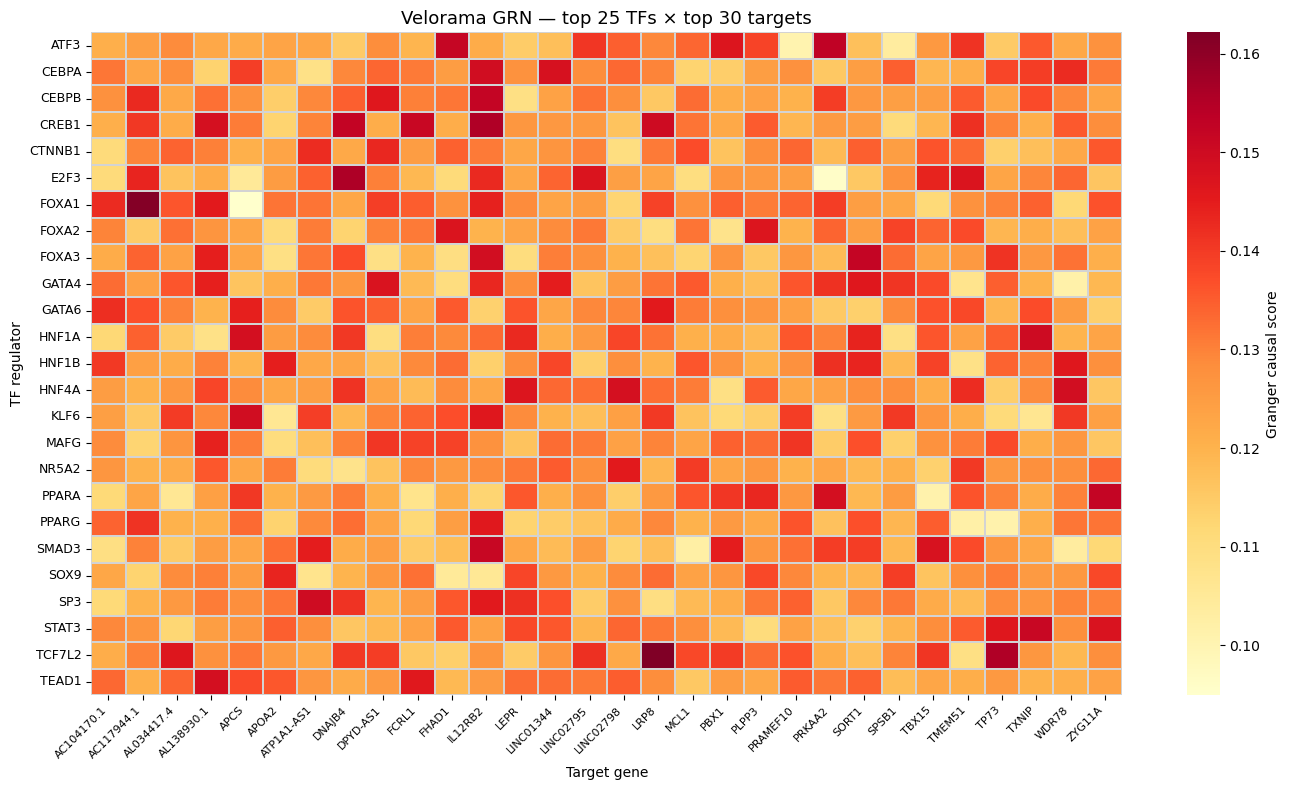

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

TOP_TF     = 25   # rows
TOP_TARGET = 30   # columns

# Select top TFs and top targets by score
top_tfs     = results.groupby("TF")["grn_score"].sum().nlargest(TOP_TF).index
top_targets = results.groupby("target")["grn_score"].sum().nlargest(TOP_TARGET).index

heatmap_data = (
    results[results["TF"].isin(top_tfs) & results["target"].isin(top_targets)]
    .pivot_table(index="TF", columns="target", values="grn_score", fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="lightgrey",
    ax=ax,
    cbar_kws={"label": "Granger causal score"},
)
ax.set_title(f"Velorama GRN — top {TOP_TF} TFs × top {TOP_TARGET} targets", fontsize=13)
ax.set_xlabel("Target gene")
ax.set_ylabel("TF regulator")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grn_heatmap.png"), dpi=150)
plt.show()

---
## Cell 16 · Visualisation 3 — Interaction speed vs. strength scatter

Velorama's key biological insight: **fast TFs** (low lag score) tend to be
pioneer / chromatin remodellers, while **slow TFs** operate through cascades.

Results columns: ['TF', 'target', 'grn_score', 'lag_score']


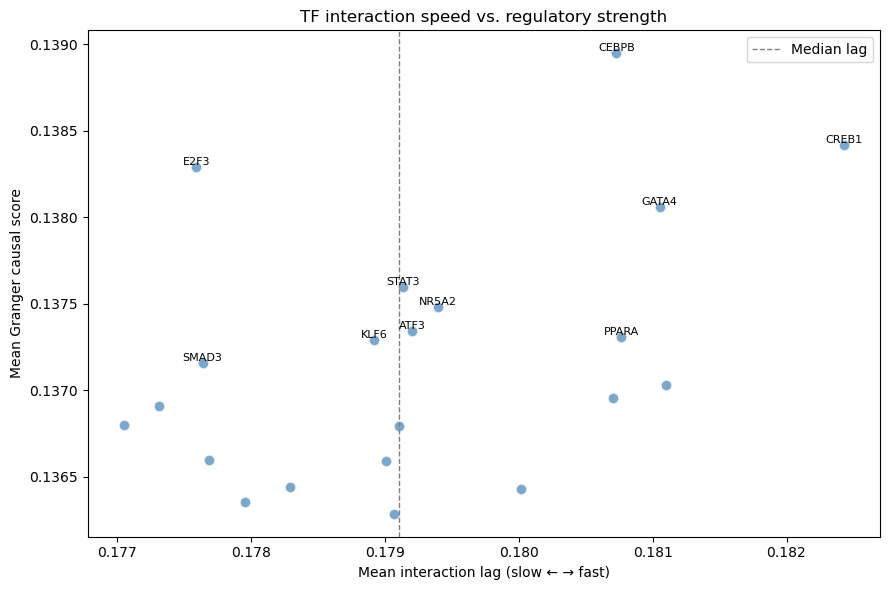

In [24]:
# ── merge lag scores into results ────────────────────────────────────────────
lag_long = (
    lag_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "lag_score"})
)
results = results.merge(lag_long, on=["TF", "target"], how="left")
print(f"Results columns: {results.columns.tolist()}")

# ── speed vs strength scatter ─────────────────────────────────────────────────
tf_stats = (
    results
    .groupby("TF")
    .apply(lambda g: g.nlargest(50, "grn_score"))
    .reset_index(drop=True)
    .groupby("TF")[["grn_score", "lag_score"]]
    .mean()
    .dropna()
)

threshold = tf_stats["grn_score"].quantile(0.5)
plot_tf   = tf_stats[tf_stats["grn_score"] >= threshold]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_tf["lag_score"], plot_tf["grn_score"],
           s=60, alpha=0.7, color="steelblue", edgecolors="white")

for tf_name, row in plot_tf.nlargest(10, "grn_score").iterrows():
    ax.annotate(tf_name, (row["lag_score"], row["grn_score"]),
                fontsize=8, ha="center", va="bottom")

ax.axvline(plot_tf["lag_score"].median(), color="grey", ls="--", lw=1, label="Median lag")
ax.set_xlabel("Mean interaction lag (slow ← → fast)")
ax.set_ylabel("Mean Granger causal score")
ax.set_title("TF interaction speed vs. regulatory strength")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tf_speed_vs_strength.png"), dpi=150)
plt.show()

---
## Cell 17 · Focus: hepatocyte-specific vs. cholangiocyte-specific TFs

Split the dataset by cell type and re-examine which TFs are most influential
in each lineage using the *same* Velorama GRN (no re-running required).

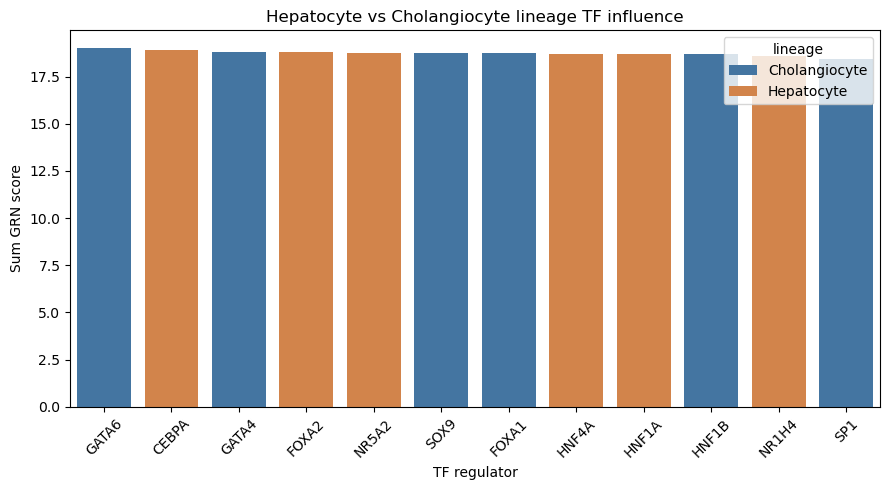

,TF,grn_score,lineage
4,GATA6,18.998946,Cholangiocyte
0,CEBPA,18.899245,Hepatocyte
3,GATA4,18.799830,Cholangiocyte
2,FOXA2,18.788451,Hepatocyte
9,NR5A2,18.773434,Hepatocyte
10,SOX9,18.755404,Cholangiocyte
1,FOXA1,18.730268,Cholangiocyte
7,HNF4A,18.704984,Hepatocyte
5,HNF1A,18.698756,Hepatocyte
6,HNF1B,18.697541,Cholangiocyte


In [25]:
# Key TFs biologically associated with each lineage (from literature)
HEPATO_TFs    = {"HNF4A", "HNF1A", "FOXA2", "CEBPA", "NR5A2", "NR1H4"}
CHOLANGIO_TFs = {"SOX9", "HNF1B", "FOXA1", "GATA4", "GATA6", "SP1"}

# Retrieve rows for these TFs from the ranked result table
lit_tfs = HEPATO_TFs | CHOLANGIO_TFs
lit_results = results[results["TF"].isin(lit_tfs)].copy()

lit_influence = (
    lit_results
    .groupby("TF")["grn_score"]
    .sum()
    .reset_index()
    .assign(lineage=lambda df: df["TF"].apply(
        lambda t: "Hepatocyte" if t in HEPATO_TFs else "Cholangiocyte"
    ))
    .sort_values("grn_score", ascending=False)
)

palette = {"Hepatocyte": "#e88035", "Cholangiocyte": "#3576b0"}

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=lit_influence,
    x="TF", y="grn_score",
    hue="lineage", palette=palette, dodge=False, ax=ax
)
ax.set_xlabel("TF regulator")
ax.set_ylabel("Sum GRN score")
ax.set_title("Hepatocyte vs Cholangiocyte lineage TF influence")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lineage_TF_comparison.png"), dpi=150)
plt.show()

lit_influence

---
## Cell 18 · Summary

| Output file | Description |
|---|---|
| `liver_endstage.h5ad` | Prepared AnnData fed to Velorama |
| `liver_endstage_grn_scores.csv` | Raw TF × target Granger causal score matrix |
| `liver_endstage_lag_scores.csv` | Raw TF × target lag / speed matrix |
| `liver_endstage_interactions_ranked.csv` | Long-format, ranked TF–target pairs |
| `top_TF_influence.png` | Bar chart: top 20 TFs by total score |
| `grn_heatmap.png` | Heatmap: top TFs × top targets |
| `tf_speed_vs_strength.png` | Speed vs. strength scatter |
| `lineage_TF_comparison.png` | Hepatocyte vs Cholangiocyte TF comparison |

**Next steps:**
- Validate top TF–target pairs against published liver ChIP-seq data (ENCODE / ChEA3)
- Re-run with `-dyn rna_velocity` if you acquire spliced/unspliced count data
- Use `results.query('TF == "HNF4A"')` to inspect targets of a specific TF
- Import the ranked edge list into Cytoscape or networkx for network topology analysis